In [1]:
# Step 2: EEG decoding


# GAO decoding analysis
# 
import pandas as pd
import glob
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, roc_auc_score
import scipy.stats as stats
from scipy.interpolate import interp1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import Parallel, delayed
from sklearn.base import clone
from mne.time_frequency import tfr_array_morlet
import pingouin as pg

from utils.gao_functions import red_color, blue_color, red_palette, blue_palette, purple_color, purple_palette, lightblue_color, lightred_color, lightblue_palette, lightred_palette, calculate_vtc, calculate_BF, plot_BF_subplot, get_image_cat, make_timecourse_plot, make_EyeCorr_timecourse_plot

# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# import numpy as np
# from scipy.io import loadmat
# import pandas as pd
import os
os.environ["R_HOME"] = r"/Library/Frameworks/R.framework/Resources"

from rpy2.robjects import r
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
import matplotlib.pyplot as plt
import seaborn as sns

bf_package=importr('BayesFactor')


# rus = RandomUnderSampler(random_state=42)

import matplotlib.pyplot as plt
from matplotlib import colors

import mne
# from mne.datasets import sample
from mne.decoding import (
    SlidingEstimator
)

# clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced'), )

# from sklearn.impute import SimpleImputer

clf = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(store_covariance=True))
experiment_name = 'GAO'


from included_subs import subs

# CHECK UD/LR MAPPING _ DO NAMES MATCH NUMBERS?
dot_direction_map = {'UD':41, 'LR':42}
cat_map = {'vehicle':31, 'food': 32}

train_image_triggers = [11, 12] #vehicle, food
train_gabor_triggers = [21, 22] #Vertical, horizontal

test_image_triggers = [31, 32]# vehicle, food
test_gabor_triggers = [41, 42]# Vertical, horizontal

# smooth_VTC = 'yes'
# if smooth_VTC == 'yes':
#     vtc_variable = 'vtc_smooth_detrended'
# elif smooth_VTC == 'no':
#     vtc_variable = 'vtc_detrended'
# else:
#     print('smooth_VTC must be either yes or no!')
font_sz = 18
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.labelsize'] = font_sz
plt.rcParams['ytick.labelsize'] = font_sz
plt.rcParams['axes.titlesize'] = font_sz
plt.rcParams['legend.fontsize'] = font_sz - 4

figdir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/figures/'

exclude_ppt_channels = 'yes'
exclude_channels = {
    '01':['TP9','Fp1','Fp2','P3'],
    '02':['CP6','T7','TP9','Fp1','Fp2'],
    '03':['F4','TP9','Fp1','Fp2'],
    '04':['TP9','Fp1','Fp2'],
    '05':['FC5','TP9','Fp1','Fp2'],
    '06':['TP9','Fp1','Fp2'],
    '07':['TP9','Fp1','Fp2'],
    '08':['T8', 'CP2', 'FT9', 'T7', 'TP9','Fp1','Fp2'],
    '09':['TP9','Fp1','Fp2'],
    '10':['T8', 'TP9','Fp1','Fp2'],
    '11':['C3', 'TP9','Fp1','Fp2'],
    '12':['TP9','Fp1','Fp2'],
    '13':['TP9','Fp1','Fp2'],
    '14':['T7','T8','FC2','P7','Cz','CP2', 'TP9','Fp1','Fp2'],
    '15':['TP9','Fp1','Fp2'],
    '16':['TP9','Fp1','Fp2'],
    '17':['TP9','Fp1','Fp2','T7','T8'],
    '18':['TP9','Fp1','Fp2','C4','FC1'],
    '19':['TP9','Fp1','Fp2','FT10','FT9','T7','FC6'],
    '20':['TP9','Fp1','Fp2'],
    '21':['TP9','Fp1','Fp2','F3','F4','T7'],
    '22':['TP9','Fp1','Fp2','FT10'],
    '23':['TP9','Fp1','Fp2'],
    '24':['TP9','Fp1','Fp2','FT10'],
    '25':['TP9','Fp1','Fp2','T7'],
    '26':['TP9','Fp1','Fp2'],
    '27':['TP9','Fp1','Fp2'],
    '28':['TP9','Fp1','Fp2','F3'],
    '29':['TP9','Fp1','Fp2','T8']
}

if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times


Reading /Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_21789/2252015209.py:128: RuntimeWarning: This filename (/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated


In [3]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class SafeImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.col_mean_ = np.nanmean(X, axis=0)
        self.global_mean_ = np.nanmean(X)
        return self

    def transform(self, X):
        X = X.copy()

        all_nan = np.all(np.isnan(X), axis=1)

        # replace all-NaN rows with global mean
        X[all_nan] = self.global_mean_

        # now safe to do column imputation
        col_nan = np.isnan(X)
        X[col_nan] = np.take(self.col_mean_, np.where(col_nan)[1])

        return X

In [6]:

from collections import defaultdict
# For aligning decoding with response times 

def train_test_classifier(x_train, y_train, x_test_dict, y_test_dict, y_image_dict, analysis_list, sub, epochs):

    # X_binned, y_binned = average_epochs_in_bins(x_train, y_train, bin_size=10)
    # print('Starting training')
    time_decod = SlidingEstimator(clf, n_jobs=None, scoring="roc_auc", verbose=True)
    time_decod.fit(x_train, y_train)
    
    # y_predictions = time_decod_image.predict(x_test)
    results_dict = defaultdict()
    for analysis in analysis_list:
        print(analysis  + ' RUNNING')
        x_test = x_test_dict[analysis]
        y_test = y_test_dict[analysis]
        y_pproba = time_decod.predict_proba(x_test)
        pd.DataFrame(y_pproba[:,:,0]).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(sub) + '_' + str(analysis) + '_pproba_eye.csv', index=None, header=None)
        y_decision = time_decod.decision_function(x_test)
        print(y_pproba.shape)
        auc = [roc_auc_score(y_test, y_pproba[:,col,1]) for col in np.arange(0,y_pproba.shape[1])]
        results_dict[analysis] = auc
        pd.DataFrame(auc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(sub) + '_' + str(analysis) + '_AUC_eye.csv', index=None, header=None)



    # # SAVE predicted probabilities for memory models later
    #     if analysis == 'image_relevant':
    #         image_labs_veh = y_image_dict[analysis]['image_x'][y_test==31]
    #         pred_prob_veh = y_pproba[:,:,0][y_test==31]
    #         avg_pred_prob_veh = np.mean(pred_prob_veh[:,epochs.times>0], axis=1)
    #         avg_pred_prob_veh_late = np.mean(pred_prob_veh[:,epochs.times>0.3], axis=1)

    #         image_labs_food = y_image_dict[analysis]['image_x'][y_test==32]
    #         pred_prob_food = y_pproba[:,:,1][y_test==32]
    #         avg_pred_prob_food  = np.mean(pred_prob_food[:,epochs.times>0], axis=1)
    #         avg_pred_prob_food_late  = np.mean(pred_prob_food[:,epochs.times>0.3], axis=1)

    #         veh_DF = pd.concat([image_labs_veh.reset_index(), pd.DataFrame(pred_prob_veh)],axis=1)
    #         veh_DF['relevance'] = 'rel'
    #         veh_DF['average_prediction'] = avg_pred_prob_veh
    #         veh_DF['average_prediction_late'] = avg_pred_prob_veh_late

    #         food_DF = pd.concat([image_labs_food.reset_index(), pd.DataFrame(pred_prob_food)],axis=1)
    #         food_DF['relevance'] = 'rel'
    #         food_DF['average_prediction'] = avg_pred_prob_food
    #         food_DF['average_prediction_late'] = avg_pred_prob_food_late
    #         mem_out_DF = pd.concat([veh_DF, food_DF], axis=0)
    #         print(mem_out_DF.to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_relevant_image_predicted_probs_parallelized.csv', index=False))


    #     if analysis == 'image_irrelevant':
    #         image_labs_veh_irrel = y_image_dict[analysis]['image_x'][y_test==31]
    #         pred_prob_veh_irrel = y_pproba[:,:,0][y_test==31]
    #         avg_pred_prob_veh_irrel = np.mean(pred_prob_veh_irrel[:,epochs.times>0], axis=1)
    #         avg_pred_prob_veh_irrel_late = np.mean(pred_prob_veh_irrel[:,epochs.times>0.3], axis=1)

    #         image_labs_food_irrel = y_image_dict[analysis]['image_x'][y_test==32]
    #         pred_prob_food_irrel = y_pproba[:,:,1][y_test==32]
    #         avg_pred_prob_food_irrel = np.mean(pred_prob_food_irrel[:,epochs.times>0], axis=1)
    #         avg_pred_prob_food_irrel_late = np.mean(pred_prob_food_irrel[:,epochs.times>0.3], axis=1)

    #         veh_DF_irrel = pd.concat([image_labs_veh_irrel.reset_index(), pd.DataFrame(pred_prob_veh_irrel)],axis=1)
    #         veh_DF_irrel['relevance'] = 'irrel'
    #         veh_DF_irrel['average_prediction'] = avg_pred_prob_veh_irrel
    #         veh_DF_irrel['average_prediction_late'] = avg_pred_prob_veh_irrel_late

    #         food_DF_irrel = pd.concat([image_labs_food_irrel.reset_index(), pd.DataFrame(pred_prob_food_irrel)],axis=1)
    #         food_DF_irrel['relevance'] = 'irrel'
    #         food_DF_irrel['average_prediction'] = avg_pred_prob_food_irrel
    #         food_DF_irrel['average_prediction_late'] = avg_pred_prob_food_irrel_late
    #         mem_out_DF = pd.concat([veh_DF_irrel, food_DF_irrel], axis=0)
    #         print(mem_out_DF.to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_irrelevant_image_predicted_probs_parallelized.csv', index=False))


    #     # Save average RTs for violin plot 
    #     rts = y_image_dict[analysis]['rt_x']
    #     # print(rts)
    #     pd.DataFrame(rts).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_{analysis}_raw_rts.csv', header=None, index=None)


        # mem_out_DF = pd.concat([veh_DF, food_DF, veh_DF_irrel, food_DF_irrel], axis=0)
        # print(mem_out_DF.to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_image_predicted_probs_parallelized.csv', index=False))

    return results_dict
    


def repeated_parallel_classification(x_train, y_train, x_test_dict, y_test_dict, y_image_dict, analysis_list, sub, epochs, n_jobs=-1):
    """
    Run classification multiple times in parallel and average predictions.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(train_test_classifier)(x_train, y_train, x_test_dict, y_test_dict, y_image_dict, analysis_list, sub, epochs)
        for i in range(1)
    )


In [36]:
FWHM = 4

for sub in subs:
    behav_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/' + sub + '/'
    eeg_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'


    behav_files = glob.glob(behav_dir + sub + '*.csv')
    print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']

    cpt_trials = behav_file[behav_file['task'].str.contains('cpt')]

    # print(cpt_trials.task)
    cpt_trials_vtc = calculate_vtc(cpt_trials, FWHM)

    behav_join_DF = pd.merge(behav_file, cpt_trials_vtc, left_index=True, right_index=True, how='outer')
    behav_join_DF.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_behav_DF_withVTC.csv')
    cpt_trials_vtc.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_CPT_DF_withVTC.csv')


    # Compare performance in and out of the zone
    in_zone = cpt_trials_vtc[(cpt_trials_vtc['vtc_smooth_detrended']<cpt_trials_vtc['vtc_smooth_median_detrended']) & (cpt_trials_vtc['correct_response']==0)]
    out_zone = cpt_trials_vtc[(cpt_trials_vtc['vtc_smooth_detrended']>cpt_trials_vtc['vtc_smooth_median_detrended']) & (cpt_trials_vtc['correct_response']==0)]

    in_acc = np.mean(in_zone['accuracy'])
    print('in the zone by VTC ' + str(in_acc))
    out_acc = np.mean(out_zone['accuracy'])
    print('out of the zone by VTC ' + str(out_acc))


    in_zone_RT = cpt_trials_vtc[(cpt_trials_vtc['detrended_RT']>cpt_trials_vtc['median_detrended_RT'])]
    out_zone_RT = cpt_trials_vtc[(cpt_trials_vtc['detrended_RT']<cpt_trials_vtc['median_detrended_RT'])]

    in_acc_RT = np.nanmean(in_zone_RT['accuracy'])
    print('in the zone by RT ' + str(in_acc_RT))
    out_acc_RT = np.nanmean(out_zone_RT['accuracy'])
    print('out of the zone by RT ' + str(out_acc_RT))

    # Load preprocessed EEG data--remove artifacts
    epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs=epochs_pre.copy().resample(200, npad='auto')
    # epochs_resampled = epochs.copy().resample(100, npad='auto')
    events = pd.read_csv(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_events.tsv', header=0, sep='\t')
    # Drop TP9
    if exclude_ppt_channels == 'yes':
        epochs.drop_channels(exclude_channels[sub])
    else:
        epochs.drop_channels(['TP9','Fp1','Fp2'])

    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    print(artifacts)

    epochs.drop(artifacts)
    events = events[~artifacts]


    behav_plusmem = behav_join_DF.copy()
    behav_join_DF = behav_join_DF[~behav_join_DF['task_x'].str.contains('memory')]
    behav_join_DF = behav_join_DF.reset_index(drop=True)
    behav_join_DF = behav_join_DF[~artifacts]


    x_data = epochs.get_data(picks=['eyegaze', 'pupil', 'eog'])

    # x_data = np.nan_to_num(x_data_withnans, nan=0)
    # x_data_eog = epochs.get_data(picks=['eog'])

    # Get labeled trials
    x_train_image_withnans = x_data[events.value.isin(train_image_triggers)]
    x_test_image_withnans = x_data[events.value.isin(test_image_triggers)]
    x_train_gabor_withnans = x_data[events.value.isin(train_gabor_triggers)]
    x_test_gabor_withnans = x_data[events.value.isin(test_gabor_triggers)]

    # replace missing values with the mean of that feature
    # x_train_image = np.nan_to_num(x_train_image_withnans, nan=np.nanmean(x_train_image_withnans))
    # x_train_gabor = np.nan_to_num(x_train_gabor_withnans, nan=np.nanmean(x_train_gabor_withnans))
    # x_test_image = np.nan_to_num(x_test_image_withnans, nan=np.nanmean(x_test_image_withnans))
    # x_test_gabor = np.nan_to_num(x_test_gabor_withnans, nan=np.nanmean(x_test_gabor_withnans))

    x_test_gabor = x_test_gabor_withnans.copy()
    x_train_gabor = x_train_gabor_withnans.copy()
    x_test_image = x_test_image_withnans.copy()
    x_train_image = x_train_image_withnans.copy()

    for feature in np.arange(0,x_test_gabor_withnans.shape[1]):
        np.nan_to_num(x_test_gabor[:,feature,:], nan=np.nanmean(x_test_gabor_withnans[:,feature,:]), copy=False)
        np.nan_to_num(x_train_gabor[:,feature,:], nan=np.nanmean(x_train_gabor_withnans[:,feature,:]), copy=False)
        np.nan_to_num(x_test_image[:,feature,:], nan=np.nanmean(x_test_image_withnans[:,feature,:]), copy=False)
        np.nan_to_num(x_train_image[:,feature,:], nan=np.nanmean(x_train_image_withnans[:,feature,:]), copy=False)

    y_train_image = events[events.value.isin(train_image_triggers)].value
    y_test_image = events[events.value.isin(test_image_triggers)].value
    y_train_gabor = events[events.value.isin(train_gabor_triggers)].value
    y_test_gabor = events[events.value.isin(test_gabor_triggers)].value

    included_trials_test_image = np.in1d(events['value'], test_image_triggers)
    included_trials_test_gabor = np.in1d(events['value'], test_gabor_triggers)

    behav_join_DF['image_cat'] = behav_join_DF['image_x'].apply(get_image_cat)
    behav_join_DF['cat_numeric'] = behav_join_DF['image_cat'].map(cat_map)
    behav_join_DF['direction_numeric'] = behav_join_DF['direction_x'].map(dot_direction_map)

    behav_test_image = behav_join_DF[included_trials_test_image]
    behav_test_image_irrel = behav_join_DF[included_trials_test_gabor]

    print(str(np.sum(y_train_image==11) + np.sum(y_train_image==12)) + ' training images')


    # Unsmoothed VTC
    x_test_image_inzone_VTC_unsmooth = x_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_median_detrended']]
    x_test_image_outzone_VTC_unsmooth = x_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_median_detrended']]
    behav_test_image_inzone_VTC_unsmooth = behav_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_median_detrended']]
    behav_test_image_outzone_VTC_unsmooth = behav_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_median_detrended']]

    # Use more extreme values of zone -- quartile
    x_test_image_inzone_VTC_unsmooth_quartile = x_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_lower_quartile_detrended']]
    x_test_image_outzone_VTC_unsmooth_quartile = x_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_upper_quartile_detrended']]
    behav_test_image_inzone_VTC_unsmooth_quartile = behav_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_lower_quartile_detrended']]
    behav_test_image_outzone_VTC_unsmooth_quartile = behav_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_upper_quartile_detrended']]



    x_test_image_inzone_RT = x_test_image[behav_test_image['detrended_RT']>behav_test_image['median_detrended_RT']]
    x_test_image_outzone_RT = x_test_image[behav_test_image['detrended_RT']<behav_test_image['median_detrended_RT']]
    behav_test_image_inzone_RT = behav_test_image[behav_test_image['detrended_RT']>behav_test_image['median_detrended_RT']]
    behav_test_image_outzone_RT = behav_test_image[behav_test_image['detrended_RT']<behav_test_image['median_detrended_RT']]


    x_test_image_inzone_RT_quartile = x_test_image[behav_test_image['detrended_RT']>behav_test_image['RT_upper_quartile']]
    x_test_image_outzone_RT_quartile = x_test_image[behav_test_image['detrended_RT']<behav_test_image['RT_lower_quartile']]
    behav_test_image_inzone_RT_quartile = behav_test_image[behav_test_image['detrended_RT']>behav_test_image['RT_upper_quartile']]
    behav_test_image_outzone_RT_quartile = behav_test_image[behav_test_image['detrended_RT']<behav_test_image['RT_lower_quartile']]

    # print(x_test_image_inzone_RT_quartile)

    behav_test_gabor = behav_join_DF[included_trials_test_gabor]
    behav_test_gabor['image_cat'] = behav_test_gabor['image_x'].apply(get_image_cat)
    behav_test_gabor['cat_numeric'] = behav_test_gabor['image_cat'].map(cat_map)
    behav_test_gabor['direction_numeric'] = behav_test_gabor['direction_x'].map(dot_direction_map)

# sub_run_df["vtc_smooth_detrended"]>sub_run_df['vtc_smooth_median_detrended']
    # x_test_gabor_inzone_VTC = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_median_detrended']]
    # x_test_gabor_outzone_VTC = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_median_detrended']]
    # behav_test_gabor_inzone_VTC = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_median_detrended']]
    # behav_test_gabor_outzone_VTC = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_median_detrended']]
  
    #Unsmoothed VTC
    x_test_gabor_inzone_VTC_unsmooth = x_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_median_detrended']]
    x_test_gabor_outzone_VTC_unsmooth = x_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_median_detrended']]
    behav_test_gabor_inzone_VTC_unsmooth = behav_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_median_detrended']]
    behav_test_gabor_outzone_VTC_unsmooth = behav_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_median_detrended']]

    x_test_gabor_inzone_RT = x_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['median_detrended_RT']]
    x_test_gabor_outzone_RT = x_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['median_detrended_RT']]
    behav_test_gabor_inzone_RT = behav_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['median_detrended_RT']]
    behav_test_gabor_outzone_RT = behav_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['median_detrended_RT']]

    x_test_gabor_inzone_RT_quartile = x_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['RT_upper_quartile']]
    x_test_gabor_outzone_RT_quartile = x_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['RT_lower_quartile']]
    behav_test_gabor_inzone_RT_quartile = behav_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['RT_upper_quartile']]
    behav_test_gabor_outzone_RT_quartile = behav_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['RT_lower_quartile']]

# Remove nans because some might be exactly equal to median

    # ## QUARTILE VTC
    # x_test_gabor_inzone_VTC_quartile = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_lower_quartile_detrended']]
    # x_test_gabor_outzone_VTC_quartile = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_upper_quartile_detrended']]
    # behav_test_gabor_inzone_VTC_quartile = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_lower_quartile_detrended']]
    # behav_test_gabor_outzone_VTC_quartile = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_upper_quartile_detrended']]
  
    # QUARTILE Unsmoothed VTC
    x_test_gabor_inzone_VTC_unsmooth_quartile = x_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_lower_quartile_detrended']]
    x_test_gabor_outzone_VTC_unsmooth_quartile = x_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_upper_quartile_detrended']]
    behav_test_gabor_inzone_VTC_unsmooth_quartile = behav_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_lower_quartile_detrended']]
    behav_test_gabor_outzone_VTC_unsmooth_quartile = behav_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_upper_quartile_detrended']]


########################################## IMAGE DECODING #########################################################


###### IMAGE DECODING
    analysis_list_image = ['image_relevant',
                     'image_irrelevant', 
                     'image_relevant_inzone_VTC_quartile',
                     'image_relevant_outzone_VTC_quartile',
                     'image_irrelevant_inzone_VTC_quartile',
                     'image_irrelevant_outzone_VTC_quartile',
                     'image_relevant_inzone_RT_quartile',
                     'image_relevant_outzone_RT_quartile',
                     'image_irrelevant_inzone_RT_quartile',
                     'image_irrelevant_outzone_RT_quartile'
                     ]


    test_x_image_dict = {
        'image_relevant': x_test_image,
        'image_irrelevant': x_test_gabor,
        'image_relevant_inzone_VTC_quartile': x_test_image_inzone_VTC_unsmooth_quartile,
        'image_relevant_outzone_VTC_quartile': x_test_image_outzone_VTC_unsmooth_quartile,
        'image_irrelevant_inzone_VTC_quartile': x_test_gabor_inzone_VTC_unsmooth_quartile,
        'image_irrelevant_outzone_VTC_quartile': x_test_gabor_outzone_VTC_unsmooth_quartile,
        'image_relevant_inzone_RT_quartile': x_test_image_inzone_RT_quartile,
        'image_relevant_outzone_RT_quartile': x_test_image_outzone_RT_quartile,
        'image_irrelevant_inzone_RT_quartile': x_test_gabor_inzone_RT_quartile,
        'image_irrelevant_outzone_RT_quartile': x_test_gabor_outzone_RT_quartile

    }

    test_y_image_dict={
        'image_relevant': y_test_image,
        'image_irrelevant': behav_test_gabor['cat_numeric'],
        'image_relevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile['cat_numeric'],
        'image_relevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile['cat_numeric'],
        'image_irrelevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile['cat_numeric'],
        'image_irrelevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile['cat_numeric'],
        'image_relevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile['cat_numeric'],
        'image_relevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile['cat_numeric'],
        'image_irrelevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile['cat_numeric'],
        'image_irrelevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile['cat_numeric']
    }

    Images_y_image_dict={
        'image_relevant': behav_test_image,
        'image_irrelevant': behav_test_gabor,
        'image_relevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile,
        'image_relevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile,
        'image_irrelevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile,
        'image_irrelevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile,
        'image_relevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile,
        'image_relevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile,
        'image_irrelevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile,
        'image_irrelevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile
    }

    
    analysis_list_gabor = [
                     'gabor_relevant',
                     'gabor_irrelevant', 
                     'gabor_relevant_inzone_VTC_quartile',
                     'gabor_relevant_outzone_VTC_quartile',
                     'gabor_irrelevant_inzone_VTC_quartile',
                     'gabor_irrelevant_outzone_VTC_quartile',
                     'gabor_relevant_inzone_RT_quartile',
                     'gabor_relevant_outzone_RT_quartile',
                     'gabor_irrelevant_inzone_RT_quartile',
                     'gabor_irrelevant_outzone_RT_quartile'  
                     ]
    
    test_x_gabor_dict = {
        'gabor_relevant':x_test_gabor,
        'gabor_irrelevant': x_test_image, 
        'gabor_relevant_inzone_VTC_quartile': x_test_gabor_inzone_VTC_unsmooth_quartile,
        'gabor_relevant_outzone_VTC_quartile': x_test_gabor_outzone_VTC_unsmooth_quartile,
        'gabor_irrelevant_inzone_VTC_quartile': x_test_image_inzone_VTC_unsmooth_quartile,
        'gabor_irrelevant_outzone_VTC_quartile': x_test_image_outzone_VTC_unsmooth_quartile,
        'gabor_relevant_inzone_RT_quartile': x_test_gabor_inzone_RT_quartile,
        'gabor_relevant_outzone_RT_quartile': x_test_gabor_outzone_RT_quartile,
        'gabor_irrelevant_inzone_RT_quartile': x_test_image_inzone_RT_quartile,
        'gabor_irrelevant_outzone_RT_quartile': x_test_image_outzone_RT_quartile
    }

    test_y_gabor_dict = {
        'gabor_relevant': y_test_gabor,
        'gabor_irrelevant': behav_test_image['direction_numeric'], 
        'gabor_relevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile['direction_numeric'],
        'gabor_relevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile['direction_numeric'],
        'gabor_irrelevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile['direction_numeric'],
        'gabor_irrelevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile['direction_numeric'],
        'gabor_relevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile['direction_numeric'],
        'gabor_relevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile['direction_numeric'],
        'gabor_irrelevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile['direction_numeric'],
        'gabor_irrelevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile['direction_numeric']

    }
    Images_y_gabor_dict = {
        'gabor_relevant': behav_test_gabor,
        'gabor_irrelevant': behav_test_image, 
        'gabor_relevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile,
        'gabor_relevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile,
        'gabor_irrelevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile,
        'gabor_irrelevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile,
        'gabor_relevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile,
        'gabor_relevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile,
        'gabor_irrelevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile,
        'gabor_irrelevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile
    }



    repeated_parallel_classification(x_train_image, y_train_image, test_x_image_dict, test_y_image_dict, Images_y_image_dict, analysis_list_image, sub, epochs, n_jobs=-1)
    # pd.DataFrame(avg_auc_image_relevant).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/' + sub + '_relevant_AUC_binned.csv', index=None, header=None)
    repeated_parallel_classification(x_train_gabor, y_train_gabor, test_x_gabor_dict, test_y_gabor_dict, Images_y_gabor_dict, analysis_list_gabor, sub, epochs, n_jobs=-1)
    # pd.DataFrame(avg_auc_image_relevant).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/' + sub + '_relevant_AUC_binned.csv', index=None, header=None)

    # # Save predicted probabilities 
    # relevant_df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_relevant_image_predicted_probs_parallelized.csv', header=None)
    # irrelevant_df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_irrelevant_image_predicted_probs_parallelized.csv', header=None)
    # mem_df = pd.concat([relevant_df, irrelevant_df], axis=0)
    # mem_df.to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_image_predicted_probs_parallelized.csv', header=False, index=False)

['/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/01/01_data_2025_Oct_29_1041_5.csv']
0.05140345076172896


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

0.05909256401758137
0.05101376202245117
0.04883439089050293
in the zone by VTC 0.7235772357723578
out of the zone by VTC 0.6666666666666666
in the zone by RT 1.0
out of the zone by RT 1.0
Reading /Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_17193/2904832200.py:49: RuntimeWarning: This filename (/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False  True False]
Dropped 2183 epochs: 2, 6, 7, 8, 9, 11, 15, 19, 20, 21, 22, 25, 28, 29, 31, 33, 35, 36, 38, 39, 40, 41, 42, 44, 46, 47, 49, 50, 54, 55, 57, 59, 60, 64, 65, 69, 73, 75, 77, 80, 84, 85, 89, 93, 96, 99, 101, 106, 108, 111, 113, 114, 118, 122, 125, 129, 130, 133, 136, 141, 142, 144, 147, 149, 151, 153, 156, 157, 158, 161, 165, 168, 170, 172, 173, 176, 177, 179, 181, 183, 186, 188, 191, 192, 194, 197, 200, 204, 205, 207, 208, 210, 213, 216, 219, 222, 228, 230, 233, 234, 235, 236, 239, 240, 241, 245, 246, 248, 251, 252, 255, 256, 260, 261, 262, 264, 266, 269, 271, 272, 273, 276, 279, 283, 285, 287, 290, 291, 293, 294, 295, 297, 298, 300, 301, 302, 303, 304, 305, 307, 310, 312, 314, 316, 318, 319, 321, 322, 324, 325, 

...

(197, 190, 2)
gabor_irrelevant_inzone_RT_quartile RUNNING


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1285.12it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00,  876.30it/s]


(194, 190, 2)
gabor_irrelevant_outzone_RT_quartile RUNNING


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1042.63it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1227.81it/s]


(175, 190, 2)


In [18]:
X = x_train_image
# X should be 2D at this point
print("Any NaNs:", np.isnan(X).sum())

# rows that are completely NaN
all_nan_rows = np.all(np.isnan(X), axis=2)
print("All-NaN rows:", all_nan_rows.sum())

# show where they are
print(np.where(all_nan_rows)[0])

Any NaNs: 380
All-NaN rows: 2
[182 182]


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative    p-val         CI95%   cohen-d   BF10  \
T-test  0.809608   24   two-sided  0.42612  [-0.0, 0.01]  0.167223  0.284   

           power  
T-test  0.126516  
0.5176697514996095
0.01883806722751807
0.514834330575019
0.014040548115782037
               T  dof alternative    p-val         CI95%   cohen-d   BF10  \
T-test  0.809608   24   two-sided  0.42612  [-0.0, 0.01]  0.167223  0.284   

           power  
T-test  0.126516  
relevant
0.5176697514996095
0.01883806722751807
irrelevant
0.514834330575019
0.014040548115782037
0.284
['$\\mathrm{BF}_{10}$ = 0.28']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

relevant vs. irrelevant: $\mathrm{BF}_{10}$ = 0.28


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


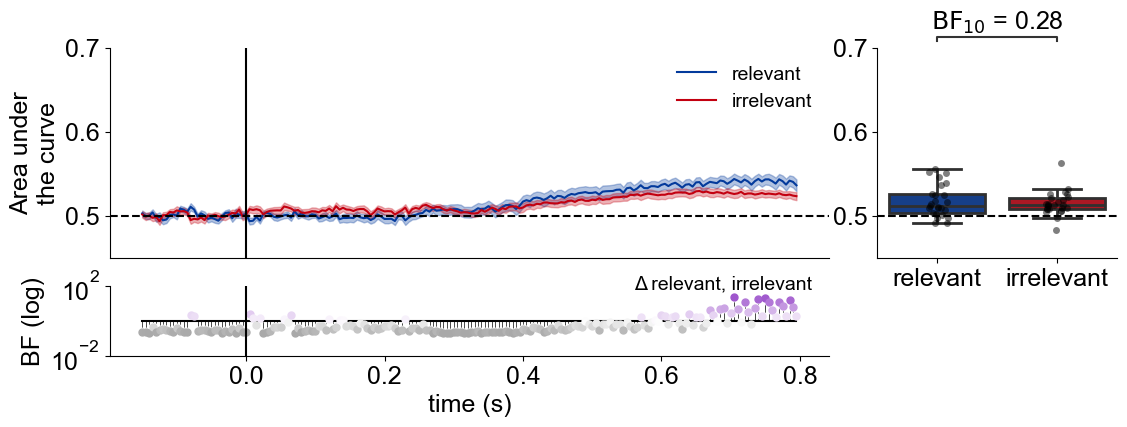

In [4]:

if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

rel_acc_df = pd.DataFrame()
irrel_acc_df = pd.DataFrame()
kfold_df = pd.DataFrame()
# subs=['01','02','03','04','05','06','07','08','10','12','13','14','15','17','18','20','21','22','23','24','25','26','27','28','29']
rel_mean = []
irrel_mean = []
# subs=['01']
for s in subs:
    # k_fold = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_image_decoding_timecourse.csv', header=None)
    # kfold_df = pd.concat([kfold_df, k_fold.T],axis=0)
    rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_AUC_eye.csv', header=None)
    rel_acc_df= pd.concat([rel_acc_df, rel_acc.T], axis=0)
    rel_mean.append(np.mean(rel_acc[epochs.times>0.0]))
    irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_AUC_eye.csv', header=None)
    irrel_acc_df= pd.concat([irrel_acc_df, irrel_acc.T], axis=0)
    irrel_mean.append(np.mean(irrel_acc[epochs.times>0.0]))

mean_rel_acc = np.mean(rel_acc_df, axis=0)
mean_irrel_acc = np.mean(irrel_acc_df, axis=0)
mean_kfold = np.mean(kfold_df, axis=0)

SE_rel = stats.sem(rel_acc_df, axis=0)
SE_irrel = stats.sem(irrel_acc_df, axis=0)
SE_kfold = stats.sem(kfold_df, axis=0)



bf_diff = calculate_BF(rel_acc_df, irrel_acc_df)


print(pg.ttest(rel_mean, irrel_mean, paired=True))
print(np.mean(rel_mean))
print(np.std(rel_mean))
print(np.mean(irrel_mean))
print(np.std(irrel_mean))

plot_dict_rel = {
    'tc1': mean_rel_acc, 
    'tc1_label': "relevant",
    'tc2': mean_irrel_acc,
    'tc2_label': "irrelevant",
    'tc1_SE': SE_rel,
    'tc2_SE': SE_irrel,
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'bar1': rel_mean,
    'bar1_label': 'relevant',
    'bar2_label': 'irrelevant',
    'bar2': irrel_mean,
    'BF': bf_diff,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 relevant, irrelevant",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'image_relirrel_eye.png'
}

make_timecourse_plot(plot_dict_rel)



/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test  0.445567   24   two-sided  0.659903  [-0.01, 0.01]  0.134148  0.231   

           power  
T-test  0.098741  
0.5046872249041623
0.012947265500866584
0.502857225571708
0.01377198079602891
               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test  0.445567   24   two-sided  0.659903  [-0.01, 0.01]  0.134148  0.231   

           power  
T-test  0.098741  
relevant
0.5046872249041623
0.012947265500866584
irrelevant
0.502857225571708
0.01377198079602891
0.231
['$\\mathrm{BF}_{10}$ = 0.23']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

relevant vs. irrelevant: $\mathrm{BF}_{10}$ = 0.23


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


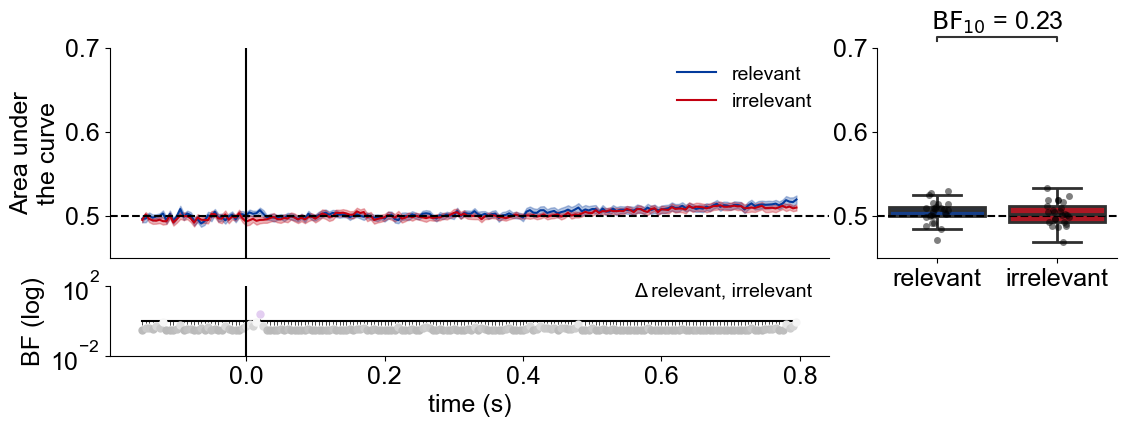

In [3]:

if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

rel_acc_df = pd.DataFrame()
irrel_acc_df = pd.DataFrame()
kfold_df = pd.DataFrame()
# subs=['01','02','03','04','05','06','07','08','10','12','13','14','15','17','18','20','21','22','23','24','25','26','27','28','29']
rel_mean = []
irrel_mean = []
# subs=['01']
for s in subs:
    # k_fold = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_image_decoding_timecourse.csv', header=None)
    # kfold_df = pd.concat([kfold_df, k_fold.T],axis=0)
    rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_AUC_eye.csv', header=None)
    rel_acc_df= pd.concat([rel_acc_df, rel_acc.T], axis=0)
    rel_mean.append(np.mean(rel_acc[epochs.times>0.0]))
    irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_AUC_eye.csv', header=None)
    irrel_acc_df= pd.concat([irrel_acc_df, irrel_acc.T], axis=0)
    irrel_mean.append(np.mean(irrel_acc[epochs.times>0.0]))

mean_rel_acc = np.mean(rel_acc_df, axis=0)
mean_irrel_acc = np.mean(irrel_acc_df, axis=0)
mean_kfold = np.mean(kfold_df, axis=0)

SE_rel = stats.sem(rel_acc_df, axis=0)
SE_irrel = stats.sem(irrel_acc_df, axis=0)
SE_kfold = stats.sem(kfold_df, axis=0)



bf_diff = calculate_BF(rel_acc_df, irrel_acc_df)


print(pg.ttest(rel_mean, irrel_mean, paired=True))
print(np.mean(rel_mean))
print(np.std(rel_mean))
print(np.mean(irrel_mean))
print(np.std(irrel_mean))

plot_dict_rel = {
    'tc1': mean_rel_acc, 
    'tc1_label': "relevant",
    'tc2': mean_irrel_acc,
    'tc2_label': "irrelevant",
    'tc1_SE': SE_rel,
    'tc2_SE': SE_irrel,
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'bar1': rel_mean,
    'bar1_label': 'relevant',
    'bar2_label': 'irrelevant',
    'bar2': irrel_mean,
    'BF': bf_diff,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 relevant, irrelevant",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'gabor_relirrel_eye.png'
}

make_timecourse_plot(plot_dict_rel)



In [39]:
nIter = 10

for s in subs:
    eeg_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_relevant_pproba_EEG.csv', header=None))
    eye_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_relevant_pproba_eye.csv', header=None))

    corr_tc=[]
    # shuff_tc = np.empty([nIter, eeg_acc.shape[1]])
    for i in np.arange(0,eeg_acc.shape[1]):
        corr_tc.append(pg.corr(eeg_acc[:,i], eye_acc[:,i]).r.pearson)

        # for n in np.arange(0,nIter):
        #     eeg_acc_shuff = eeg_acc[:,i].copy()
        #     np.random.shuffle(eeg_acc_shuff)
        #     shuff_tc[n,i] = pg.corr(eeg_acc_shuff, eye_acc[:,i]).r.pearson

    pd.DataFrame(corr_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_relevant_EEGeyeCorr.csv', header=None, index=None)
    # pd.DataFrame(shuff_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_relevant_EEGeyeCorr_shuffled.csv', header=None, index=None)



    eeg_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_irrelevant_pproba_EEG.csv', header=None))
    eye_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_irrelevant_pproba_eye.csv', header=None))

    corr_tc=[]
    # shuff_tc = np.empty([nIter, eeg_acc.shape[1]])
    for i in np.arange(0,eeg_acc.shape[1]):
        corr_tc.append(pg.corr(eeg_acc[:,i], eye_acc[:,i]).r.pearson)
        # for n in np.arange(0,nIter):
        #     eeg_acc_shuff = eeg_acc[:,i].copy()
        #     np.random.shuffle(eeg_acc_shuff)
        #     shuff_tc[n,i] = pg.corr(eeg_acc_shuff, eye_acc[:,i]).r.pearson
    pd.DataFrame(corr_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_irrelevant_EEGeyeCorr.csv', header=None, index=None)
    # pd.DataFrame(shuff_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_irrelevant_EEGeyeCorr_shuffled.csv', header=None, index=None)


    eeg_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_relevant_pproba_EEG.csv', header=None))
    eye_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_relevant_pproba_eye.csv', header=None))

    corr_tc=[]
    # shuff_tc = np.empty([nIter, eeg_acc.shape[1]])
    for i in np.arange(0,eeg_acc.shape[1]):
        corr_tc.append(pg.corr(eeg_acc[:,i], eye_acc[:,i]).r.pearson)
        # for n in np.arange(0,nIter):
        #     eeg_acc_shuff = eeg_acc[:,i].copy()
        #     np.random.shuffle(eeg_acc_shuff)
        #     shuff_tc[n,i] = pg.corr(eeg_acc_shuff, eye_acc[:,i]).r.pearson
    pd.DataFrame(corr_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_relevant_EEGeyeCorr.csv', header=None, index=None)
    # pd.DataFrame(shuff_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_relevant_EEGeyeCorr_shuffled.csv', header=None, index=None)



    eeg_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_irrelevant_pproba_EEG.csv', header=None))
    eye_acc = np.array(pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_irrelevant_pproba_eye.csv', header=None))

    corr_tc=[]
    # shuff_tc = np.empty([nIter, eeg_acc.shape[1]])
    for i in np.arange(0,eeg_acc.shape[1]):
        corr_tc.append(pg.corr(eeg_acc[:,i], eye_acc[:,i]).r.pearson)
        # for n in np.arange(0,nIter):
        #     eeg_acc_shuff = eeg_acc[:,i].copy()
        #     np.random.shuffle(eeg_acc_shuff)
        #     shuff_tc[n,i] = pg.corr(eeg_acc_shuff, eye_acc[:,i]).r.pearson
    pd.DataFrame(corr_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_irrelevant_EEGeyeCorr.csv', header=None, index=None)
    # pd.DataFrame(shuff_tc).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_irrelevant_EEGeyeCorr_shuffled.csv', header=None, index=None)

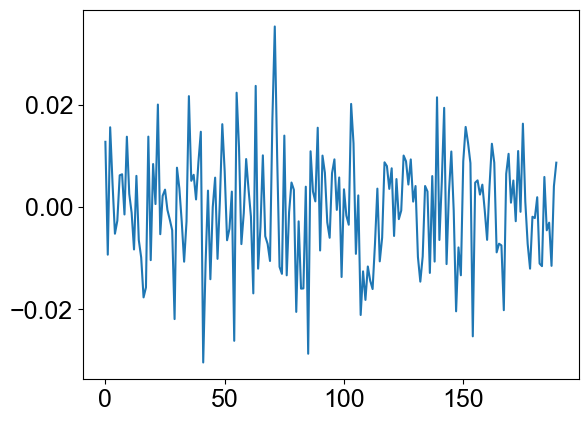

In [75]:
plt.plot(np.mean(shuff_tc, axis=0))

/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val         CI95%   cohen-d   BF10  \
T-test -1.533709   24   two-sided  0.138179  [-0.02, 0.0]  0.250811  0.592   

           power  
T-test  0.225679  
relevant
in-zone
0.011470940392607286
0.026822573829442486
relevant
out-of-zone
0.017977271938171387
0.023929111039520667
0.592
['$\\mathrm{BF}_{10}$ = 0.59']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

relevant
in-zone vs. relevant
out-of-zone: $\mathrm{BF}_{10}$ = 0.59


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


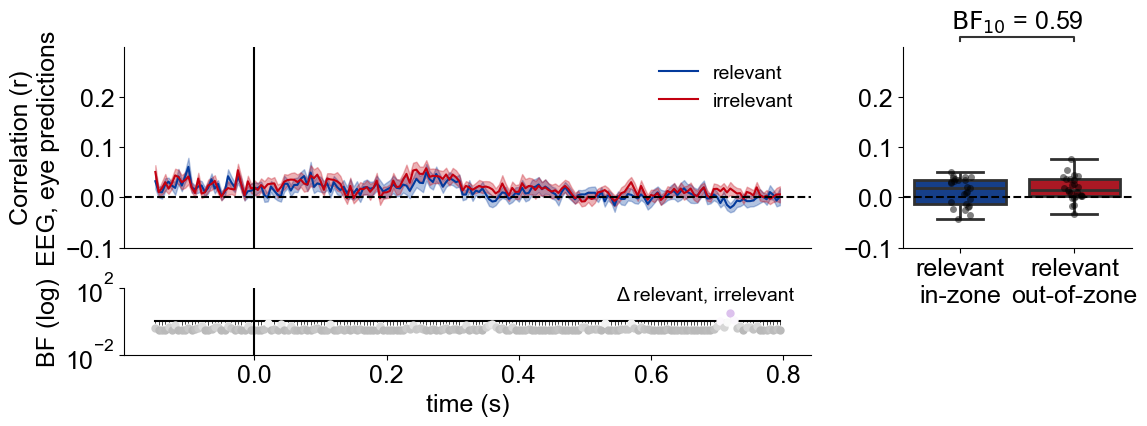

In [4]:
corr_df = pd.DataFrame()
corr_df_irrel = pd.DataFrame()

rel_mean = []
irrel_mean = []
for s in subs:
    corr= pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_relevant_EEGeyeCorr.csv', header=None)
    corr_df =pd.concat([corr_df, corr.T], axis=0)
    rel_mean.append(np.mean(corr[epochs.times>0.0]))
    # in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    # print(corr_df.shape)

    corr_irrel= pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_image_irrelevant_EEGeyeCorr.csv', header=None)
    corr_df_irrel =pd.concat([corr_df_irrel, corr_irrel.T], axis=0)
    irrel_mean.append(np.mean(corr_irrel[epochs.times>0.0]))

    # print(corr_df_irrel.shape)


mean_corr = np.mean(corr_df, axis=0)
mean_corr_irrel = np.mean(corr_df_irrel, axis=0)

SE_corr = stats.sem(corr_df, axis=0)
SE_corr_irrel = stats.sem(corr_df_irrel, axis=0)

bf_diff = calculate_BF(corr_df, corr_df_irrel)




plot_dict_rel = {
    'tc1': mean_corr, 
    'tc1_label': "relevant",
    'tc2': mean_corr_irrel,
    'tc2_label': "irrelevant",
    'tc1_SE': SE_corr,
    'tc2_SE': SE_corr_irrel,
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'bar1': rel_mean,
    'bar1_label': 'relevant\nin-zone',
    'bar2_label': 'relevant\nout-of-zone',
    'bar2': irrel_mean,
    'BF': bf_diff,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 relevant, irrelevant",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'EyeEEGCorr_Image.png'
}

make_EyeCorr_timecourse_plot(plot_dict_rel)

# fig, ax_dec = plt.subplots()
# ax_dec.plot(x_axis, mean_corr, color='#033A9C', label="relevant")
# ax_dec.fill_between(x_axis, mean_corr - SE_corr, mean_corr + SE_corr, color=blue_color, alpha=0.3)

# ax_dec.plot(x_axis, mean_corr_irrel, color=red_color, label="irrelevant")
# ax_dec.fill_between(x_axis, mean_corr_irrel - SE_corr_irrel, mean_corr_irrel + SE_corr_irrel, color=red_color, alpha=0.3)

# # ax_dec.plot(x_axis, mean_irrel_acc, red_color, label="irrelevant")
# # ax_dec.fill_between(x_axis, mean_irrel_acc - SE_irrel, mean_irrel_acc + SE_irrel, color=red_color, alpha=0.3)
# ax_dec.set_ylim(-0.1, 0.3)
# ax_dec.set_yticks([-0.1, 0, 0.1, 0.2])
# # ax_dec.set_xticks([1, 2, 3, 4, 5])
# ax_dec.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
# # ax.plot(test_epochs.times, mean_y_pred_vehicle, label="score")
# # ax[0].get_xaxis().get_major_formatter().labelOnlyBase = True
# ax_dec.axvline(0.0, color="k", linestyle="-")
# ax_dec.axhline(0.0, color="k", linestyle="--")

# ax_dec.spines['right'].set_visible(False)
# ax_dec.spines['top'].set_visible(False)
# ax_dec.axhline(0.5, color="k", linestyle="--")
# ax_dec.set_ylabel("Correlation (r)\nEEG, eye predictions", fontsize=font_sz)  # Area Under the Curve
# ax_dec.legend(frameon=False, framealpha=0)
# ax_dec.axvline(0.0, color="k", linestyle="-")
# # ax_dec.set_title("Image category decoding", fontsize=font_sz)
# ax_dec.set_xticks([])

/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test -0.573405   24   two-sided  0.571705  [-0.01, 0.01]  0.072126  0.245   

           power  
T-test  0.063858  
relevant
in-zone
0.03265768201036652
0.03694919095148584
relevant
out-of-zone
0.03506727121198244
0.027886632664410747
0.245
['$\\mathrm{BF}_{10}$ = 0.24']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

relevant
in-zone vs. relevant
out-of-zone: $\mathrm{BF}_{10}$ = 0.24


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


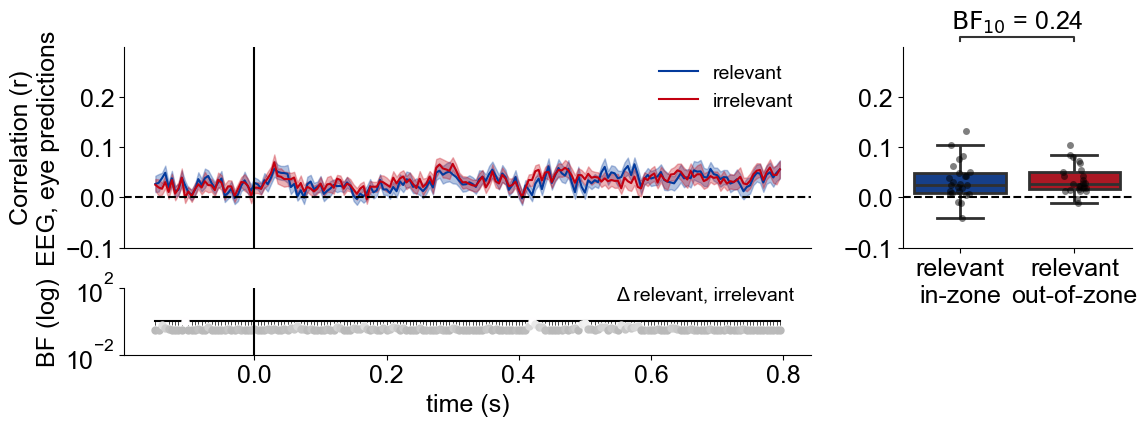

In [5]:
corr_df = pd.DataFrame()
corr_df_irrel = pd.DataFrame()
rel_mean = []
irrel_mean = []
for s in subs:
    corr= pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_relevant_EEGeyeCorr.csv', header=None)
    corr_df =pd.concat([corr_df, corr.T], axis=0)
    rel_mean.append(np.mean(corr[epochs.times>0.0]))
    # print(corr_df.shape)

    corr_irrel= pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + str(s) + '_gabor_irrelevant_EEGeyeCorr.csv', header=None)
    corr_df_irrel =pd.concat([corr_df_irrel, corr_irrel.T], axis=0)
    irrel_mean.append(np.mean(corr_irrel[epochs.times>0.0]))

    # print(corr_df_irrel.shape)


mean_corr = np.mean(corr_df, axis=0)
mean_corr_irrel = np.mean(corr_df_irrel, axis=0)

SE_corr = stats.sem(corr_df, axis=0)
SE_corr_irrel = stats.sem(corr_df_irrel, axis=0)


bf_diff = calculate_BF(corr_df, corr_df_irrel)






plot_dict_rel = {
    'tc1': mean_corr, 
    'tc1_label': "relevant",
    'tc2': mean_corr_irrel,
    'tc2_label': "irrelevant",
    'tc1_SE': SE_corr,
    'tc2_SE': SE_corr_irrel,
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'bar1': rel_mean,
    'bar1_label': 'relevant\nin-zone',
    'bar2_label': 'relevant\nout-of-zone',
    'bar2': irrel_mean,
    'BF': bf_diff,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 relevant, irrelevant",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'EyeEEGCorr_Gabor.png'
}

make_EyeCorr_timecourse_plot(plot_dict_rel)



# fig, ax_dec = plt.subplots(figsize=(10, 4))
# ax_dec.plot(x_axis, mean_corr, color='#033A9C', label="relevant")
# ax_dec.fill_between(x_axis, mean_corr - SE_corr, mean_corr + SE_corr, color=blue_color, alpha=0.3)

# ax_dec.plot(x_axis, mean_corr_irrel, color=red_color, label="irrelevant")
# ax_dec.fill_between(x_axis, mean_corr_irrel - SE_corr_irrel, mean_corr_irrel + SE_corr_irrel, color=red_color, alpha=0.3)

# # ax_dec.plot(x_axis, mean_irrel_acc, red_color, label="irrelevant")
# # ax_dec.fill_between(x_axis, mean_irrel_acc - SE_irrel, mean_irrel_acc + SE_irrel, color=red_color, alpha=0.3)
# ax_dec.set_ylim(-0.1, 0.3)
# ax_dec.set_yticks([-0.1, 0, 0.1, 0.2])
# ax_dec.set_xticks([0, 0.2, 0.4, 0.6, 0.8])
# # ax.plot(test_epochs.times, mean_y_pred_vehicle, label="score")
# # ax[0].get_xaxis().get_major_formatter().labelOnlyBase = True
# ax_dec.axvline(0.0, color="k", linestyle="-")
# ax_dec.axhline(0.0, color="k", linestyle="--")

# ax_dec.spines['right'].set_visible(False)
# ax_dec.spines['top'].set_visible(False)
# ax_dec.axhline(0.5, color="k", linestyle="--")
# ax_dec.set_ylabel("Correlation (r)\nEEG, eye predictions", fontsize=font_sz)  # Area Under the Curve
# ax_dec.legend(frameon=False, framealpha=0)
# ax_dec.axvline(0.0, color="k", linestyle="-")
# # ax_dec.set_title("Gabor", fontsize=font_sz)
# # ax_dec.set_xticks([])

/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val        CI95%   cohen-d   BF10  \
T-test  2.827797   24   two-sided  0.009307  [0.0, 0.01]  0.724535  5.078   

           power  
T-test  0.935027  
0.5123186126741723
0.008979851822049016
0.5057444981315543
0.00879970613492276
               T  dof alternative     p-val        CI95%   cohen-d   BF10  \
T-test  2.827797   24   two-sided  0.009307  [0.0, 0.01]  0.724535  5.078   

           power  
T-test  0.935027  


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


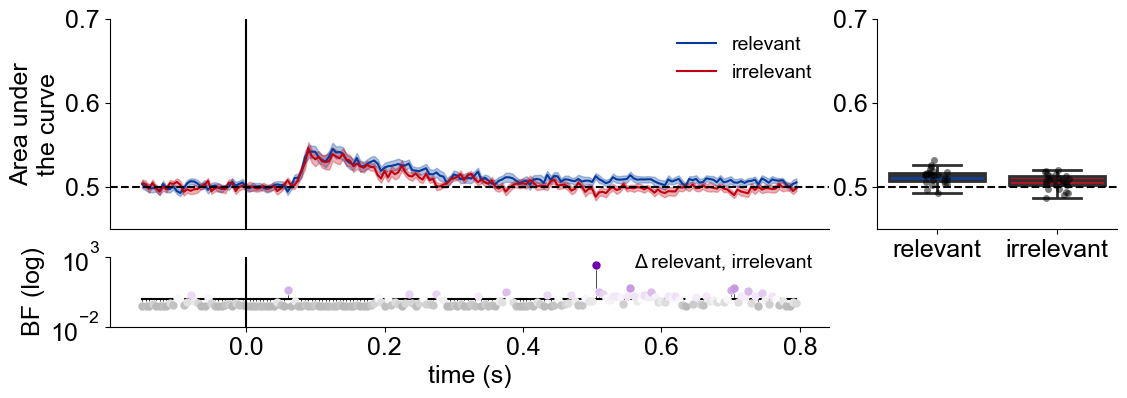

In [107]:
# clf = make_pipeline(StandardScaler(), LogisticRegression(solver="liblinear"))
rel_acc_df = pd.DataFrame()
irrel_acc_df = pd.DataFrame()
kfold_df = pd.DataFrame()
rel_mean = []
irrel_mean = []
# subs=['01','02','03','04','05','06','07','08','09','10','11','12','13','14']
for s in subs:
    k_fold = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_gabor_decoding_timecourse.csv', header=None)
    kfold_df = pd.concat([kfold_df, k_fold.T],axis=0)
    rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/gabor_decoding/' + s + '_relevant_AUC.csv', header=None)
    rel_acc_df= pd.concat([rel_acc_df, rel_acc.T], axis=0)
    rel_mean.append(np.mean(rel_acc[epochs.times>0.0]))
    irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/gabor_decoding/' + s + '_irrelevant_AUC.csv', header=None)
    irrel_acc_df= pd.concat([irrel_acc_df, irrel_acc.T], axis=0)
    irrel_mean.append(np.mean(irrel_acc[epochs.times>0.0]))

mean_rel_acc = np.mean(rel_acc_df, axis=0)
mean_irrel_acc = np.mean(irrel_acc_df, axis=0)
mean_kfold = np.mean(kfold_df, axis=0)

SE_rel = stats.sem(rel_acc_df, axis=0)
SE_irrel = stats.sem(irrel_acc_df, axis=0)
SE_kfold = stats.sem(kfold_df, axis=0)



bf_diff = calculate_BF(rel_acc_df, irrel_acc_df)


print(pg.ttest(rel_mean, irrel_mean, paired=True))
print(np.mean(rel_mean))
print(np.std(rel_mean))
print(np.mean(irrel_mean))
print(np.std(irrel_mean))
# figname = figdir + 'Fig1_RelIrrel_BF.png'
# f
# ig = plt.figure(figsize=(15, 6))

# gs = fig.add_gridspec(
#     nrows=2,
#     ncols=3,
#     width_ratios=[5, 1, 1],
#     height_ratios=[3, 1],
#     wspace=0.1,
#     hspace=0.4
# )

# # Left column
# ax_dec = fig.add_subplot(gs[0, 0])
# ax_bf = fig.add_subplot(gs[1, 0])

# # Right side of decoding plot
# ax_rel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
# ax_irrel = fig.add_subplot(gs[0, 2], sharey=ax_dec)




# # fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), gridspec_kw={'wspace': 0.4, 'hspace': 0.4, 'height_ratios': [3, 1]})
# ax_dec.plot(x_axis, mean_rel_acc, color='#033A9C', label="relevant")
# ax_dec.fill_between(x_axis, mean_rel_acc - SE_rel, mean_rel_acc + SE_rel, color=blue_color, alpha=0.3)

# ax_dec.plot(x_axis, mean_irrel_acc, red_color, label="irrelevant")
# ax_dec.fill_between(x_axis, mean_irrel_acc - SE_irrel, mean_irrel_acc + SE_irrel, color=red_color, alpha=0.3)
# ax_dec.set_ylim(0.45, 0.7)
# ax_dec.set_yticks([0.5, 0.6, 0.7])
# # ax.plot(test_epochs.times, mean_y_pred_vehicle, label="score")
# # ax[0].get_xaxis().get_major_formatter().labelOnlyBase = True
# # ax.axvline(0.0, color="k", linestyle="-")

# ax_dec.spines['right'].set_visible(False)
# ax_dec.spines['top'].set_visible(False)
# ax_dec.axhline(0.5, color="k", linestyle="--")
# ax_dec.set_ylabel("Area under\nthe curve", fontsize=font_sz)  # Area Under the Curve
# ax_dec.legend(frameon=False, framealpha=0)
# ax_dec.axvline(0.0, color="k", linestyle="-")
# ax_dec.set_title("Gabor orientation decoding", fontsize=font_sz)
# ax_dec.set_xticks([])


# # fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 6), sharey=True)
# # sns.violinplot(rel_mean, cut=0, color=blue_color, linewidth=0, ax=ax[0])
# sns.boxplot(rel_mean, color=blue_color, linewidth=2, fliersize=0, ax=ax_rel)
# sns.stripplot(rel_mean, color="black", alpha=0.5, ax=ax_rel)
# ax_rel.scatter(0,np.mean(rel_mean), color='white')
# ax_rel.set_xticklabels({'relevant'})

# # sns.violinplot(irrel_mean, cut=0, color=red_color,linewidth=0, ax=ax[1])
# sns.boxplot(irrel_mean, color=red_color,linewidth=2, ax=ax_irrel)
# sns.stripplot(irrel_mean, color="black", alpha=0.5, ax=ax_irrel)
# ax_irrel.scatter(0,np.mean(irrel_mean), color='white')
# ax_irrel.set_xticklabels({'irrelevant'})
# ax_irrel.tick_params(left=False)
# # ax_irrel.set_yticks([])
# sns.despine(right=True)

# # ax_rel.tick_params(axis='y', left=False, labelleft=False)
# ax_irrel.tick_params(axis='y', left=False, labelleft=False)

# plot_BF_subplot(x_axis, bf_diff, purple_palette, ax=ax_bf, title="\u0394 relevant, irrelevant", topLim=3, bottomLim=2, xlabel=True)
# # plt.show()
# plt.savefig(figdir + 'Fig2B_gabor_relirrel_onsetlocked.png', bbox_inches='tight')
# plt.show()


# print(pg.ttest(rel_mean, irrel_mean, paired=True))






plot_dict_rel = {
    'tc1': mean_rel_acc, 
    'tc1_label': "relevant",
    'tc2': mean_irrel_acc,
    'tc2_label': "irrelevant",
    'tc1_SE': SE_rel,
    'tc2_SE': SE_irrel,
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'bar1': rel_mean,
    'bar1_label': 'relevant',
    'bar2_label': 'irrelevant',
    'bar2': irrel_mean,
    'BF': bf_diff,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 relevant, irrelevant",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig2B_gabor_onsetlocked.png'
}

make_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


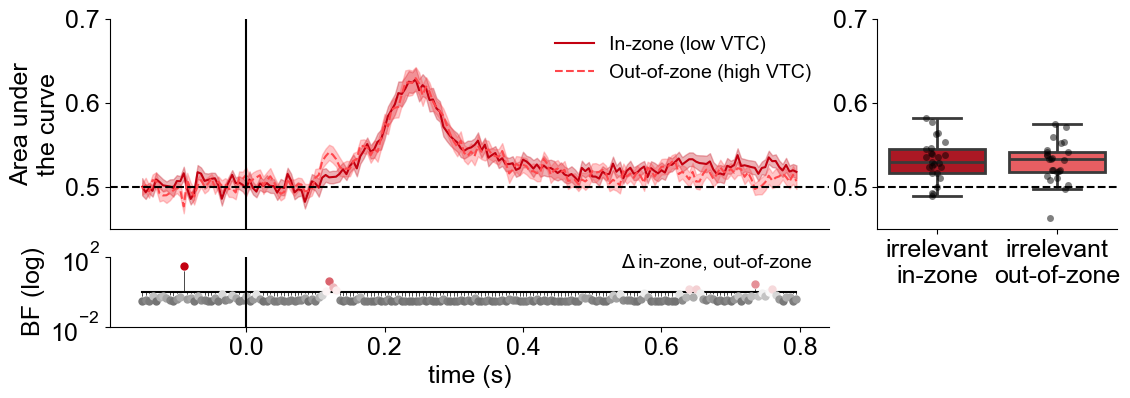

/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


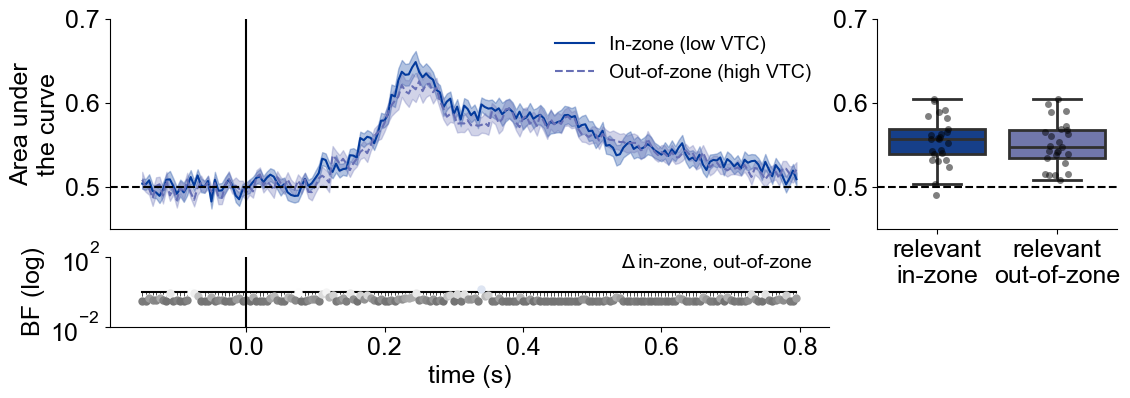

In [99]:
#### VTC split, 

in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

mean_rt_in_rel = []
mean_rt_out_rel = []
mean_rt_in_irrel = []
mean_rt_out_irrel = []
# subs=['01','02','03','04','05','06','07','08','10','12','13','14',]
all_rts_in_rel = pd.DataFrame()
all_rts_out_rel = pd.DataFrame()
all_rts_in_irrel = pd.DataFrame()
all_rts_out_irrel = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_inzone_VTC_quartile_AUC.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_outzone_VTC_quartile_AUC.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_inzone_VTC_quartile_AUC.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_outzone_VTC_quartile_AUC.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

    # # Save RTs for violin plot
    # rts_in_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_rel = pd.concat([all_rts_in_rel, rts_in_rel], axis=0)
    # mean_rt_in_rel.append(np.nanmean(rts_in_rel))
    # rts_out_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_rel = pd.concat([all_rts_out_rel, rts_out_rel], axis=0)
    # mean_rt_out_rel.append(np.nanmean(rts_out_rel))
    # rts_in_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_irrel = pd.concat([all_rts_in_irrel, rts_in_irrel], axis=0)
    # mean_rt_in_irrel.append(np.nanmean(rts_in_irrel))
    # rts_out_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_irrel = pd.concat([all_rts_out_irrel, rts_out_irrel], axis=0)
    # mean_rt_out_irrel.append(np.nanmean(rts_out_irrel))


mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)


bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)


plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "In-zone (low VTC)",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "Out-of-zone (high VTC)",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'irrelevant\nin-zone',
    'bar2_label': 'irrelevant\nout-of-zone',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 in-zone, out-of-zone",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3B_image_irrel_inout_onsetlocked.png'
}


make_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "In-zone (low VTC)",
    'tc2': mean_out_rel_acc,
    'tc2_label': "Out-of-zone (high VTC)",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'relevant\nin-zone',
    'bar2_label': 'relevant\nout-of-zone',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 in-zone, out-of-zone",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3B_image_rel_inout_onsetlocked.png'
}

make_timecourse_plot(plot_dict_rel)


               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test  0.549947   24   two-sided  0.587438  [-0.01, 0.01]  0.104846  0.242   

           power  
T-test  0.079519  


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


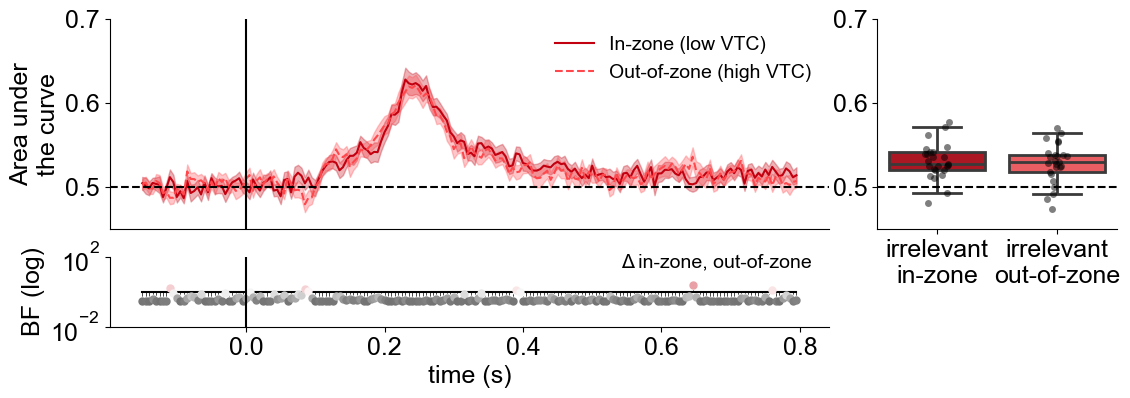

               T  dof alternative    p-val          CI95%   cohen-d   BF10  \
T-test -0.493249   24   two-sided  0.62632  [-0.01, 0.01]  0.089438  0.236   

           power  
T-test  0.071394  


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


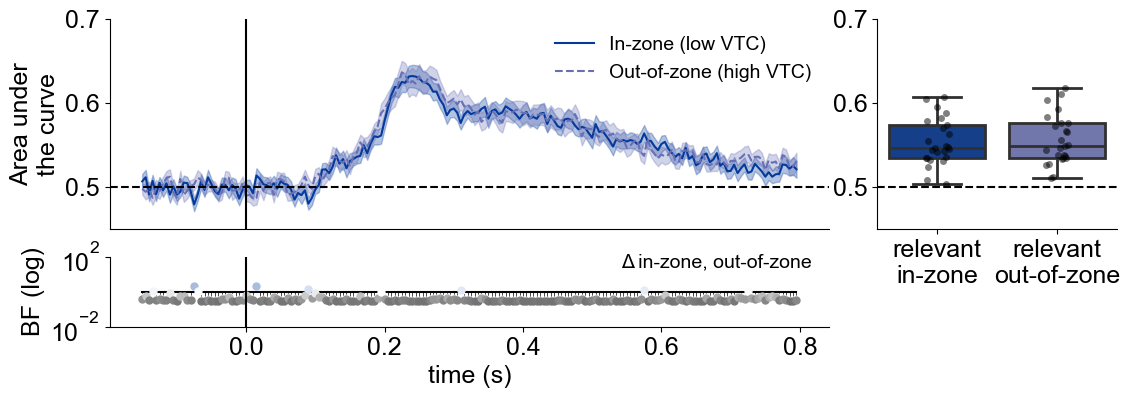

In [104]:
plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "In-zone (low VTC)",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "Out-of-zone (high VTC)",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'irrelevant\nin-zone',
    'bar2_label': 'irrelevant\nout-of-zone',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 in-zone, out-of-zone",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3B_image_irrel_inout_onsetlocked.png'
}


make_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "In-zone (low VTC)",
    'tc2': mean_out_rel_acc,
    'tc2_label': "Out-of-zone (high VTC)",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'relevant\nin-zone',
    'bar2_label': 'relevant\nout-of-zone',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 in-zone, out-of-zone",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3B_image_rel_inout_onsetlocked.png'
}

make_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


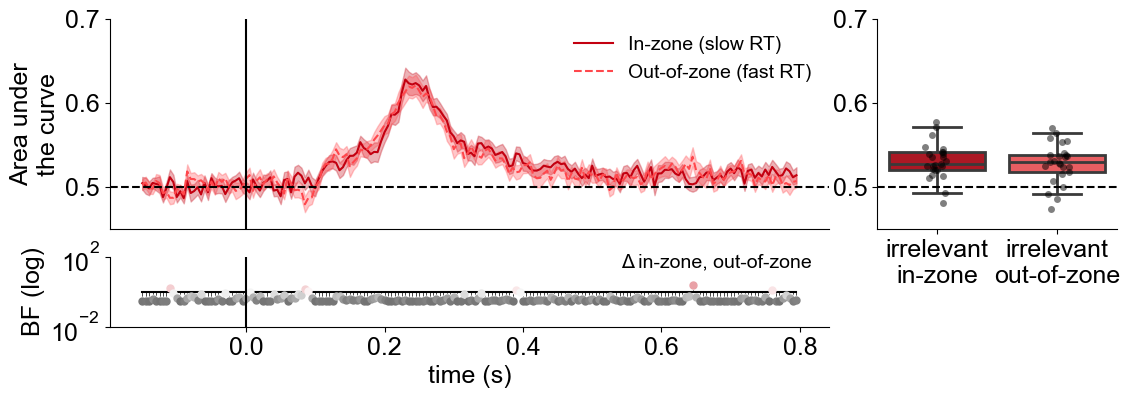

/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


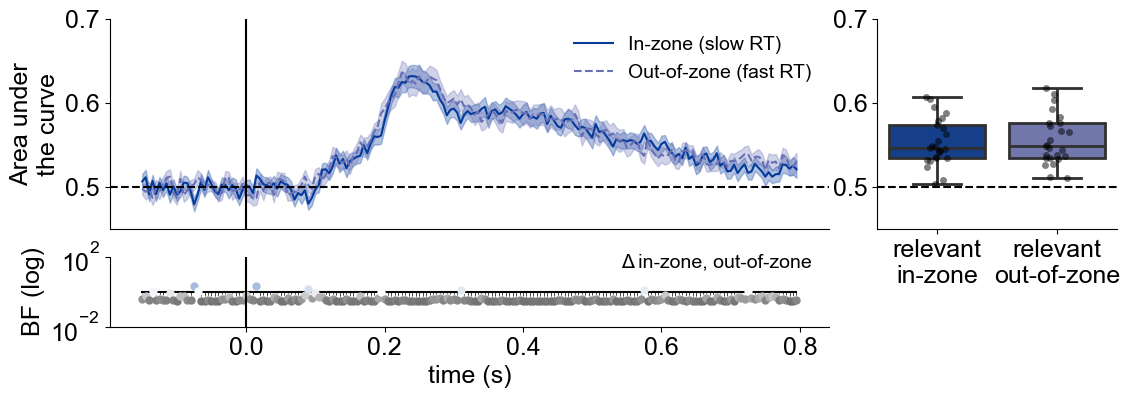

In [100]:
#### VTC split, 

in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

mean_rt_in_rel = []
mean_rt_out_rel = []
mean_rt_in_irrel = []
mean_rt_out_irrel = []
# subs=['01','02','03','04','05','06','07','08','10','12','13','14',]
all_rts_in_rel = pd.DataFrame()
all_rts_out_rel = pd.DataFrame()
all_rts_in_irrel = pd.DataFrame()
all_rts_out_irrel = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_inzone_RT_quartile_AUC.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_outzone_RT_quartile_AUC.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_inzone_RT_quartile_AUC.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_outzone_RT_quartile_AUC.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

    # # Save RTs for violin plot
    # rts_in_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_rel = pd.concat([all_rts_in_rel, rts_in_rel], axis=0)
    # mean_rt_in_rel.append(np.nanmean(rts_in_rel))
    # rts_out_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_rel = pd.concat([all_rts_out_rel, rts_out_rel], axis=0)
    # mean_rt_out_rel.append(np.nanmean(rts_out_rel))
    # rts_in_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_irrel = pd.concat([all_rts_in_irrel, rts_in_irrel], axis=0)
    # mean_rt_in_irrel.append(np.nanmean(rts_in_irrel))
    # rts_out_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_irrel = pd.concat([all_rts_out_irrel, rts_out_irrel], axis=0)
    # mean_rt_out_irrel.append(np.nanmean(rts_out_irrel))


mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)


bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)

plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "In-zone (slow RT)",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "Out-of-zone (fast RT)",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'irrelevant\nin-zone',
    'bar2_label': 'irrelevant\nout-of-zone',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 in-zone, out-of-zone",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3C_image_irrel_inout_onsetlocked_RT.png'
}


make_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "In-zone (slow RT)",
    'tc2': mean_out_rel_acc,
    'tc2_label': "Out-of-zone (fast RT)",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'relevant\nin-zone',
    'bar2_label': 'relevant\nout-of-zone',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 in-zone, out-of-zone",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3D_image_rel_inout_onsetlocked_RT.png'
}

make_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_36070/1229702393.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_36070/1229702393.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_in_rel.set_xticklabels({'relevant\nin-zone'})
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_36070/1229702393.py:131: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

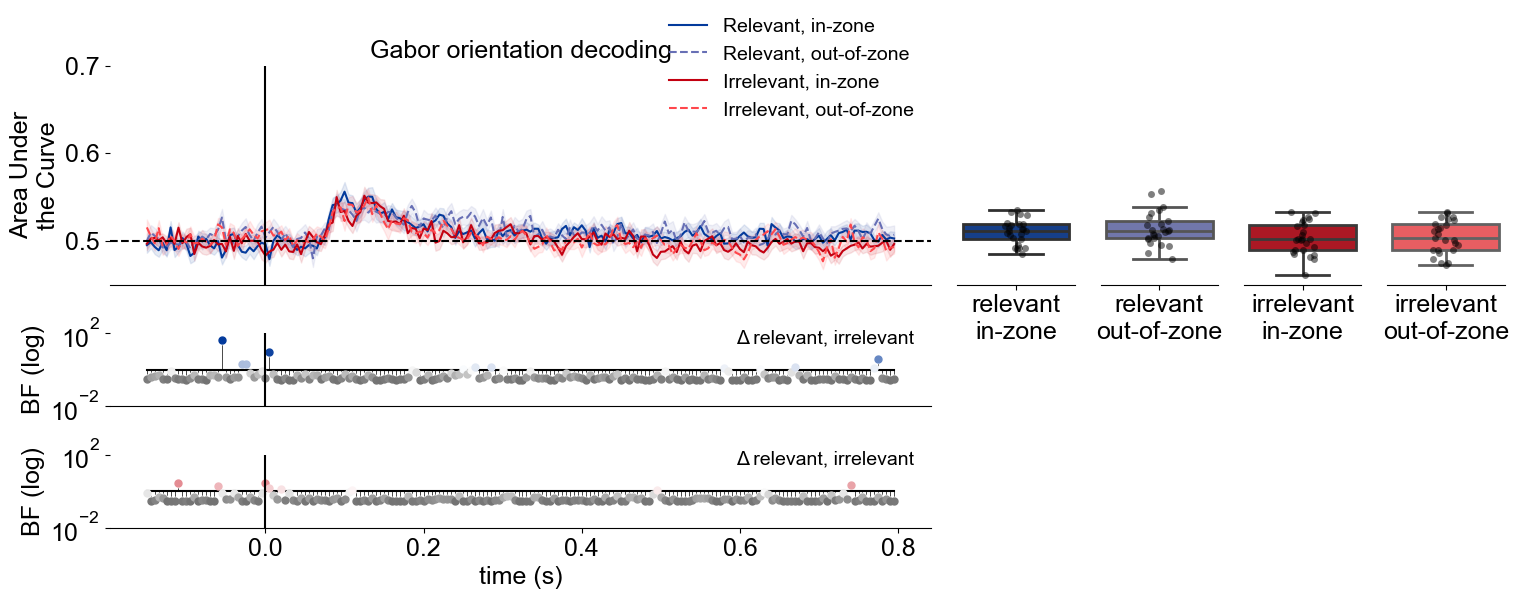

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_36070/1229702393.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_in_rel.set_xticklabels({'relevant\nin-zone'})
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_36070/1229702393.py:258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_out_rel.set_xticklabels({'relevant\nout-of-zone'})
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


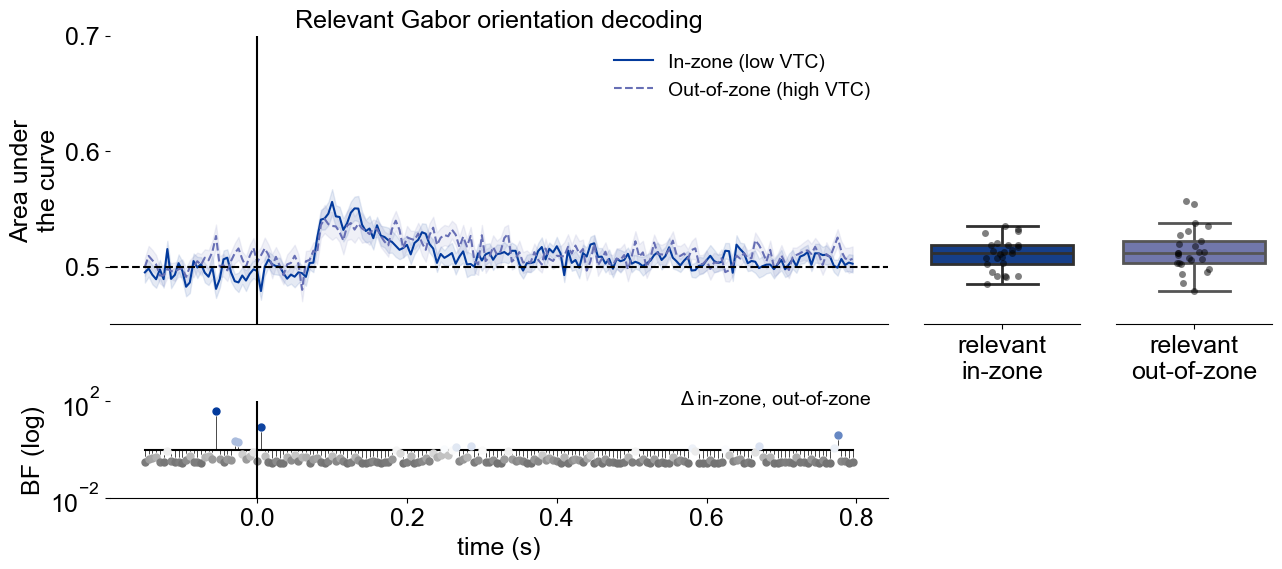

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_36070/1229702393.py:320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_in_irrel.set_xticklabels({'irrelevant\nin-zone'})
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_36070/1229702393.py:326: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_out_irrel.set_xticklabels({'irrelevant\nout-of-zone'})
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


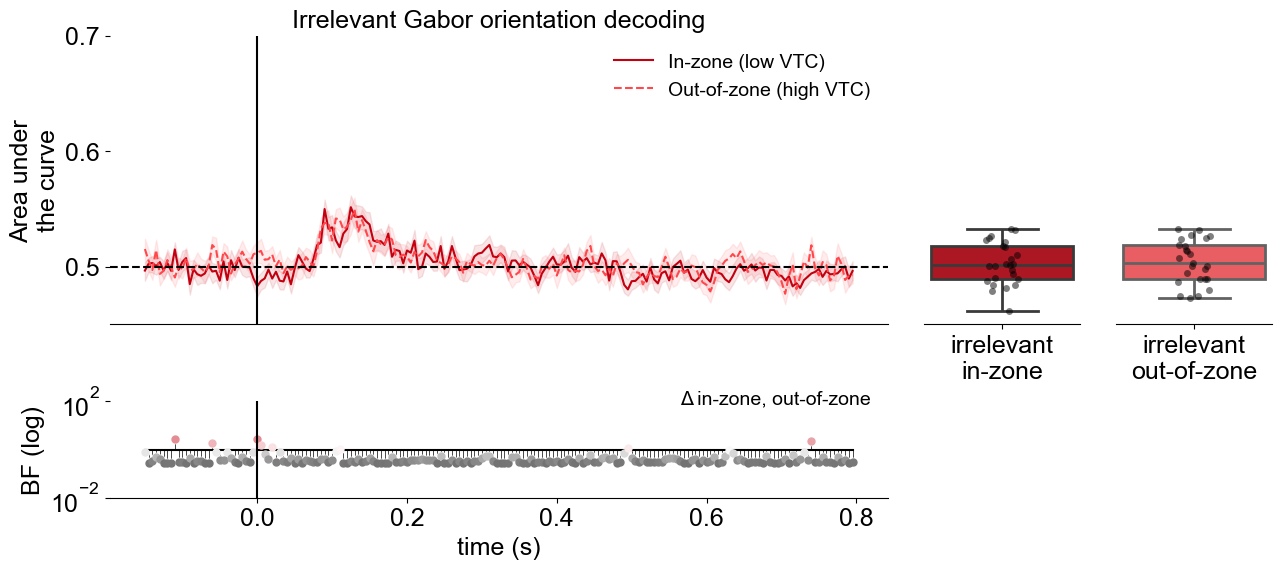

In [48]:
#### VTC split, 

in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

mean_rt_in_rel = []
mean_rt_out_rel = []
mean_rt_in_irrel = []
mean_rt_out_irrel = []
# subs=['01','02','03','04','05','06','07','08','10','12','13','14',]
all_rts_in_rel = pd.DataFrame()
all_rts_out_rel = pd.DataFrame()
all_rts_in_irrel = pd.DataFrame()
all_rts_out_irrel = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_inzone_VTC_quartile_AUC.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_outzone_VTC_quartile_AUC.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_inzone_VTC_quartile_AUC.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_outzone_VTC_quartile_AUC.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

    # # Save RTs for violin plot
    # rts_in_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_rel = pd.concat([all_rts_in_rel, rts_in_rel], axis=0)
    # mean_rt_in_rel.append(np.nanmean(rts_in_rel))
    # rts_out_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_rel = pd.concat([all_rts_out_rel, rts_out_rel], axis=0)
    # mean_rt_out_rel.append(np.nanmean(rts_out_rel))
    # rts_in_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_irrel = pd.concat([all_rts_in_irrel, rts_in_irrel], axis=0)
    # mean_rt_in_irrel.append(np.nanmean(rts_in_irrel))
    # rts_out_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_irrel = pd.concat([all_rts_out_irrel, rts_out_irrel], axis=0)
    # mean_rt_out_irrel.append(np.nanmean(rts_out_irrel))


mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)


bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)


#### PLOT FOR  BLRB
fig = plt.figure(figsize=(18, 6))

gs = fig.add_gridspec(
    nrows=3,
    ncols=5,
    width_ratios=[7, 1, 1, 1, 1],
    height_ratios=[3, 1, 1],
    wspace=0.1,
    hspace=0.4
)

# Left column
ax_dec = fig.add_subplot(gs[0, 0])
ax_bf1 = fig.add_subplot(gs[1, 0])
ax_bf2 = fig.add_subplot(gs[2, 0])

# Right side of decoding plot
ax_in_rel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
ax_out_rel = fig.add_subplot(gs[0, 2], sharey=ax_dec)
ax_in_irrel = fig.add_subplot(gs[0, 3], sharey=ax_dec)
ax_out_irrel = fig.add_subplot(gs[0, 4], sharey=ax_dec)




# fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), gridspec_kw={'wspace': 0.4, 'hspace': 0.4, 'height_ratios': [3, 1, 1]})
ax_dec.plot(epochs.times, mean_in_rel_acc, '#033A9C', linestyle='-',label="Relevant, in-zone")
ax_dec.fill_between(x_axis, mean_in_rel_acc - SE_in_rel, mean_in_rel_acc + SE_in_rel, color=blue_color, alpha=0.1)
ax_dec.plot(epochs.times, mean_out_rel_acc, '#676FB5', linestyle='--', label="Relevant, out-of-zone")
ax_dec.fill_between(x_axis, mean_out_rel_acc - SE_out_rel, mean_out_rel_acc + SE_out_rel, color=lightblue_color, alpha=0.1)
ax_dec.plot(epochs.times, mean_in_irrel_acc, red_color, linestyle='-', label="Irrelevant, in-zone")
ax_dec.fill_between(x_axis, mean_in_irrel_acc - SE_in_irrel, mean_in_irrel_acc + SE_in_irrel, color=red_color, alpha=0.1)
ax_dec.plot(epochs.times, mean_out_irrel_acc, lightred_color, linestyle='--', label="Irrelevant, out-of-zone")
ax_dec.fill_between(x_axis, mean_out_irrel_acc - SE_out_irrel, mean_out_irrel_acc + SE_out_irrel, color=lightred_color, alpha=0.1)
ax_dec.spines['right'].set_visible(False)
ax_dec.spines['top'].set_visible(False)
ax_dec.set_ylim(0.45, 0.7)
ax_dec.axhline(0.5, color="k", linestyle="--")
ax_dec.set_ylabel("Area Under\nthe Curve", fontsize=font_sz)  # Area Under the Curve
ax_dec.legend(frameon=False, framealpha=0, bbox_to_anchor=(1.0, 1.3))
ax_dec.axvline(0.0, color="k", linestyle="-")
ax_dec.set_title("Gabor orientation decoding", fontsize=font_sz)
ax_dec.set_xticks([])
plt.tight_layout()




# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 6), sharey=True)
# sns.violinplot(rel_mean, cut=0, color=blue_color, linewidth=0, ax=ax[0])
sns.boxplot(in_rel_mean, color=blue_color, linewidth=2, fliersize=0, ax=ax_in_rel)
sns.stripplot(in_rel_mean, color="black", alpha=0.5, ax=ax_in_rel)
ax_in_rel.scatter(0,np.mean(in_rel_mean), color='white')
ax_in_rel.set_xticklabels({'relevant\nin-zone'})


sns.boxplot(out_rel_mean, color=lightblue_color, linewidth=2, fliersize=0, ax=ax_out_rel)
sns.stripplot(out_rel_mean, color="black", alpha=0.5, ax=ax_out_rel)
ax_out_rel.scatter(0,np.mean(out_rel_mean), color='white')
ax_out_rel.set_xticklabels({'relevant\nout-of-zone'})

# sns.violinplot(irrel_mean, cut=0, color=red_color,linewidth=0, ax=ax[1])
sns.boxplot(in_irrel_mean, color=red_color,linewidth=2, fliersize=0,ax=ax_in_irrel)
sns.stripplot(in_irrel_mean, color="black", alpha=0.5, ax=ax_in_irrel)
ax_in_irrel.scatter(0,np.mean(in_irrel_mean), color='white')
ax_in_irrel.set_xticklabels({'irrelevant\nin-zone'})
ax_in_irrel.tick_params(left=False)

sns.boxplot(out_irrel_mean, color=lightred_color,linewidth=2, fliersize=0,ax=ax_out_irrel)
sns.stripplot(out_irrel_mean, color="black", alpha=0.5, ax=ax_out_irrel)
ax_out_irrel.scatter(0,np.mean(out_irrel_mean), color='white')
ax_out_irrel.set_xticklabels({'irrelevant\nout-of-zone'})
# ax_irrel.set_yticks([])
sns.despine(left=True)

ax_in_rel.tick_params(axis='y', left=False, labelleft=False)
ax_in_irrel.tick_params(axis='y', left=False, labelleft=False)
ax_out_rel.tick_params(axis='y', left=False, labelleft=False)
ax_out_irrel.tick_params(axis='y', left=False, labelleft=False)


plot_BF_subplot(x_axis, bf_diff_inout, blue_palette, ax=ax_bf1, title="\u0394 relevant, irrelevant", topLim=2, bottomLim=2, xlabel=False)
plot_BF_subplot(x_axis, bf_diff_inoutirrel, red_palette, ax=ax_bf2, title="\u0394 relevant, irrelevant", topLim=2, bottomLim=2, xlabel=True)

# plt.show()
plt.savefig(figdir + 'Fig3_gabor_VTCsplit_onsetlocked.png', bbox_inches='tight')
plt.show()





# ### Plot RTs

# fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(8, 6), sharey=True)
# # sns.violinplot(in_rel_mean, cut=0, color=blue_color, linewidth=0, ax=ax[0])
# sns.boxplot(in_rel_mean, color=blue_color, linewidth=2, fliersize=0, ax=ax[0])
# sns.stripplot(in_rel_mean, color="black", alpha=0.5, ax=ax[0])
# ax[0].scatter(0,np.mean(in_rel_mean), color='white')
# ax[0].set_ylim(0.4, 0.7)
# ax[0].set_ylabel("mean decoding")
# ax[0].set_xticklabels({'relevant\nin-zone'})

# # sns.violinplot(out_rel_mean, cut=0, color=lightblue_color,linewidth=0, ax=ax[1])
# sns.boxplot(out_rel_mean, color=lightblue_color, linewidth=2, fliersize=0, ax=ax[1])
# sns.stripplot(out_rel_mean, color="black", alpha=0.5, ax=ax[1])
# ax[1].scatter(0,np.mean(out_rel_mean), color='white')
# ax[1].set_xticklabels({'relevant\nout-of-zone'})
# ax[1].tick_params(left=False)


# # sns.violinplot(in_irrel_mean, cut=0, color=red_color, linewidth=0, ax=ax[2])
# sns.boxplot(in_irrel_mean, color=red_color, linewidth=2, fliersize=0, ax=ax[2])
# sns.stripplot(in_irrel_mean, color="black", alpha=0.5, ax=ax[2])
# ax[2].scatter(0,np.mean(in_irrel_mean), color='white')
# ax[2].set_xticklabels({'irrelevant\nin-zone'})
# ax[2].tick_params(left=False)


# # sns.violinplot(out_irrel_mean, cut=0, color=lightred_color, linewidth=0, ax=ax[3])
# sns.boxplot(out_irrel_mean, color=lightred_color, linewidth=2, fliersize=0, ax=ax[3])
# sns.stripplot(out_irrel_mean, color="black", alpha=0.5, ax=ax[3])
# ax[3].scatter(0,np.mean(out_irrel_mean), color='white')
# ax[3].set_xticklabels({'irrelevant\nout-of-zone'})
# ax[3].tick_params(left=False)
# sns.despine(left=True)

# plt.savefig(figdir + 'Fig2C_image_mean_decoding.png')


# print(pg.ttest(in_rel_mean, out_rel_mean, paired=True))
# print(pg.ttest(in_irrel_mean, out_irrel_mean, paired=True))



fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=[5, 1, 1],
    height_ratios=[3, 1],
    wspace=0.1,
    hspace=0.4
)

# Left column
ax_dec = fig.add_subplot(gs[0, 0])
ax_bf = fig.add_subplot(gs[1, 0])

# Right side of decoding plot
ax_in_rel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
ax_out_rel = fig.add_subplot(gs[0, 2], sharey=ax_dec)


# fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), gridspec_kw={'wspace': 0.4, 'hspace': 0.4, 'height_ratios': [3, 1]})
ax_dec.plot(epochs.times, mean_in_rel_acc, '#033A9C', linestyle='-',label="In-zone (low VTC)")
ax_dec.fill_between(x_axis, mean_in_rel_acc - SE_in_rel, mean_in_rel_acc + SE_in_rel, color=blue_color, alpha=0.1)
ax_dec.plot(epochs.times, mean_out_rel_acc, '#676FB5', linestyle='--', label="Out-of-zone (high VTC)")
ax_dec.fill_between(x_axis, mean_out_rel_acc - SE_out_rel, mean_out_rel_acc + SE_out_rel, color=lightblue_color, alpha=0.1)
ax_dec.set_ylim(0.45, 0.7)
ax_dec.set_yticks([0.5, 0.6, 0.7])
# ax.plot(test_epochs.times, mean_y_pred_vehicle, label="score")
# ax[0].get_xaxis().get_major_formatter().labelOnlyBase = True
# ax.axvline(0.0, color="k", linestyle="-")

ax_dec.spines['right'].set_visible(False)
ax_dec.spines['top'].set_visible(False)
ax_dec.axhline(0.5, color="k", linestyle="--")
ax_dec.set_ylabel("Area under\nthe curve", fontsize=font_sz)  # Area Under the Curve
ax_dec.legend(frameon=False, framealpha=0)
ax_dec.axvline(0.0, color="k", linestyle="-")
ax_dec.set_title("Relevant Gabor orientation decoding", fontsize=font_sz)
ax_dec.set_xticks([])


# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 6), sharey=True)
# sns.violinplot(rel_mean, cut=0, color=blue_color, linewidth=0, ax=ax[0])
sns.boxplot(in_rel_mean, color=blue_color, linewidth=2, fliersize=0, ax=ax_in_rel)
sns.stripplot(in_rel_mean, color="black", alpha=0.5, ax=ax_in_rel)
ax_in_rel.scatter(0,np.mean(in_rel_mean), color='white')
ax_in_rel.set_xticklabels({'relevant\nin-zone'})


sns.boxplot(out_rel_mean, color=lightblue_color, linewidth=2, fliersize=0, ax=ax_out_rel)
sns.stripplot(out_rel_mean, color="black", alpha=0.5, ax=ax_out_rel)
ax_out_rel.scatter(0,np.mean(out_rel_mean), color='white')
ax_out_rel.set_xticklabels({'relevant\nout-of-zone'})
ax_out_rel.tick_params(left=False)
# ax_irrel.set_yticks([])
sns.despine(left=True)

ax_in_rel.tick_params(axis='y', left=False, labelleft=False)
ax_out_rel.tick_params(axis='y', left=False, labelleft=False)

plot_BF_subplot(x_axis, bf_diff_inout, blue_palette, ax=ax_bf, title="\u0394 in-zone, out-of-zone", topLim=2, bottomLim=2, xlabel=True)
# plt.show()
plt.savefig(figdir + 'Fig3A_gabor_rel_inout_onsetlocked.png', bbox_inches='tight')
plt.show()





fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=[5, 1, 1],
    height_ratios=[3, 1],
    wspace=0.1,
    hspace=0.4
)

# Left column
ax_dec = fig.add_subplot(gs[0, 0])
ax_bf = fig.add_subplot(gs[1, 0])

# Right side of decoding plot
ax_in_irrel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
ax_out_irrel = fig.add_subplot(gs[0, 2], sharey=ax_dec)


# fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), gridspec_kw={'wspace': 0.4, 'hspace': 0.4, 'height_ratios': [3, 1]})
ax_dec.plot(epochs.times, mean_in_irrel_acc, red_color, linestyle='-',label="In-zone (low VTC)")
ax_dec.fill_between(x_axis, mean_in_irrel_acc - SE_in_rel, mean_in_irrel_acc + SE_in_irrel, color=red_color, alpha=0.1)
ax_dec.plot(epochs.times, mean_out_irrel_acc, lightred_color, linestyle='--', label="Out-of-zone (high VTC)")
ax_dec.fill_between(x_axis, mean_out_irrel_acc - SE_out_irrel, mean_out_irrel_acc + SE_out_irrel, color=lightred_color, alpha=0.1)
ax_dec.set_ylim(0.45, 0.7)
ax_dec.set_yticks([0.5, 0.6, 0.7])
# ax.plot(test_epochs.times, mean_y_pred_vehicle, label="score")
# ax[0].get_xaxis().get_major_formatter().labelOnlyBase = True
# ax.axvline(0.0, color="k", linestyle="-")

ax_dec.spines['right'].set_visible(False)
ax_dec.spines['top'].set_visible(False)
ax_dec.axhline(0.5, color="k", linestyle="--")
ax_dec.set_ylabel("Area under\nthe curve", fontsize=font_sz)  # Area Under the Curve
ax_dec.legend(frameon=False, framealpha=0)
ax_dec.axvline(0.0, color="k", linestyle="-")
ax_dec.set_title("Irrelevant Gabor orientation decoding", fontsize=font_sz)
ax_dec.set_xticks([])


# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 6), sharey=True)
# sns.violinplot(rel_mean, cut=0, color=blue_color, linewidth=0, ax=ax[0])
sns.boxplot(in_irrel_mean, color=red_color, linewidth=2, fliersize=0, ax=ax_in_irrel)
sns.stripplot(in_irrel_mean, color="black", alpha=0.5, ax=ax_in_irrel)
ax_in_irrel.scatter(0,np.mean(in_irrel_mean), color='white')
ax_in_irrel.set_xticklabels({'irrelevant\nin-zone'})


sns.boxplot(out_irrel_mean, color=lightred_color, linewidth=2, fliersize=0, ax=ax_out_irrel)
sns.stripplot(out_irrel_mean, color="black", alpha=0.5, ax=ax_out_irrel)
ax_out_irrel.scatter(0,np.mean(out_irrel_mean), color='white')
ax_out_irrel.set_xticklabels({'irrelevant\nout-of-zone'})
ax_out_irrel.tick_params(left=False)
# ax_irrel.set_yticks([])
sns.despine(left=True)

ax_in_irrel.tick_params(axis='y', left=False, labelleft=False)
ax_out_irrel.tick_params(axis='y', left=False, labelleft=False)

plot_BF_subplot(x_axis, bf_diff_inoutirrel, red_palette, ax=ax_bf, title="\u0394 in-zone, out-of-zone", topLim=2, bottomLim=2, xlabel=True)
# plt.show()
plt.savefig(figdir + 'Fig3B_gabor_irrel_inout_onsetlocked.png', bbox_inches='tight')
plt.show()


